# ✅ Updated: Custom Ten-Armed Gaussian Bandit using Gymnasium

In [73]:
# !pip install gymnasium matplotlib

In [74]:

import numpy as np
import random
import matplotlib.pyplot as plt
from gymnasium import Env, spaces


In [75]:

class TenArmedGaussianBandit(Env):
    def __init__(self):
        super().__init__()
        self.k = 10
        self.action_space = spaces.Discrete(self.k)
        self.observation_space = spaces.Discrete(1)
        self.q_true = np.random.normal(0, 1, self.k)
        self.std_dev = 1

    def reset(self, seed=None, options=None):
        return 0, {}

    def step(self, action):
        assert self.action_space.contains(action)
        reward = np.random.normal(self.q_true[action], self.std_dev)
        return 0, reward, False, False, {}


In [76]:

# Create environment instance
env = TenArmedGaussianBandit()
print("Number of arms:", env.action_space.n)
print("True reward means:", env.q_true)


Number of arms: 10
True reward means: [-0.89821835  0.31050914  1.03619374  1.99264348 -1.75739387 -1.08551111
 -0.24009308  0.08927651  1.46281836 -1.0150477 ]


# ✅ Repaired Notebook using Gymnasium and Custom Bandit Environment

In [77]:
# Install if needed
# !pip install gymnasium matplotlib


In [78]:

import numpy as np
import random
import matplotlib.pyplot as plt
from gymnasium import Env, spaces


In [79]:

class TwoArmedBanditEnv(Env):
    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Discrete(1)
        self.p_dist = [0.8, 0.2]

    def reset(self, seed=None, options=None):
        return 0, {}

    def step(self, action):
        reward = 1 if random.random() < self.p_dist[action] else 0
        return 0, reward, False, False, {}


In [80]:

def run_epsilon_greedy(env, episodes=1000, epsilon=0.1):
    Q = np.zeros(env.action_space.n)
    N = np.zeros(env.action_space.n)
    rewards = []
    for _ in range(episodes):
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q)
        _, reward, _, _, _ = env.step(action)
        rewards.append(reward)
        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]
    return rewards


In [81]:

def run_ucb(env, episodes=1000, c=2):
    Q = np.zeros(env.action_space.n)
    N = np.zeros(env.action_space.n)
    rewards = []
    for t in range(1, episodes + 1):
        if 0 in N:
            action = np.argmin(N)
        else:
            ucb_values = Q + c * np.sqrt(np.log(t) / N)
            action = np.argmax(ucb_values)
        _, reward, _, _, _ = env.step(action)
        rewards.append(reward)
        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]
    return rewards


In [82]:

def run_thompson_sampling(env, episodes=1000):
    successes = np.zeros(env.action_space.n)
    failures = np.zeros(env.action_space.n)
    rewards = []
    for _ in range(episodes):
        theta = [np.random.beta(successes[a] + 1, failures[a] + 1) for a in range(env.action_space.n)]
        action = np.argmax(theta)
        _, reward, _, _, _ = env.step(action)
        rewards.append(reward)
        if reward == 1:
            successes[action] += 1
        else:
            failures[action] += 1
    return rewards


In [83]:

def plot_avg_rewards(*reward_lists, labels):
    plt.figure(figsize=(12, 6))
    for rewards, label in zip(reward_lists, labels):
        cumulative_avg = np.cumsum(rewards) / (np.arange(1, len(rewards) + 1))
        plt.plot(cumulative_avg, label=label)
    plt.title("Cumulative Average Reward Comparison")
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.grid(True)
    plt.show()


# Multi Armed Bandit Problem

Multi-armed bandit (MAB) problem is one of the classical problems in reinforcement learning. A multi-armed bandit is actually a slot machine, a gambling game played in a casino where you pull the arm(lever) and get a payout(reward) based on some randomly generated probability distribution.  A single slot machine is called one-armed bandit and when there are multiple slot machines it is called as multi-armed bandits or k-armed bandits. Multi-armed bandits are shown below,

![MBA](./images/B09792_06_01.png)

As each slot machine gives us the reward from its own probability distribution, our goal is to find out which slot machine will give us the maximum cumulative reward over a sequence of time.So at each time step t, the agent performs an action i.e pulls an arm from the slot machine and receives a reward  and goal of our agent is to maximize the cumulative reward. 

We define the value of an arm Q(a) as average rewards received by pulling the arm, 

$$Q(a) = \frac{Sum \,of \,rewards \,\,received \,from \,the \,arm}{Total\, number \,of \,times \,the \,arm \,was \,pulled} $$

So the optimal arm is the one which gives us maximum cumulative reward i.e 

$$Q(a^*)= Max \; Q(a) $$

The goal of our agent is to find the optimal arm and also to minimize the regret which can be defined as the cost of knowing which of the k arms is optimal. Now how do we find the best arm? Whether we should explore all the arms or choose the arm which already gives us a maximum cumulative reward? Here comes exploration-exploitation dilemma. Now we will see how to solve this dilemma using various exploration strategies as follows,

1. Epsilon-greedy policy
2. Softmax exploration
3. Upper Confidence bound algorithm
4. Thomson sampling technique

First let us import the libraries,

In [84]:
import gym_bandits
import gym
import numpy as np
import math
import random
 

### Epsilon-Greedy Policy

In [85]:
def epsilon_greedy(epsilon):
    
    rand = np.random.random()  
    if rand < epsilon:
        action =  env.action_space.sample()
    else:
        action = np.argmax(Q)
    
    return action

 Now, let us initialize all the necessary variables

In [86]:
# number of rounds (iterations)
num_rounds = 20000

# Count of number of times an arm was pulled
count = np.zeros(10)

# Sum of rewards of each arm
sum_rewards = np.zeros(10)

# Q value which is the average reward
Q = np.zeros(10)

In [87]:
env.reset()

(0, {})

 Start pulling the arm!!!!!!!!

In [88]:
for i in range(num_rounds):
    
    # Select the arm using epsilon greedy 
    arm = epsilon_greedy(0.5)
    
    # Get the reward
    _, reward, terminated, truncated, _ = env.step(arm)  # ✅ Correct for Gymnasium    
    # update the count of that arm
    count[arm] += 1
    
    # Sum the rewards obtained from the arm
    sum_rewards[arm]+=reward
    
    # calculate Q value which is the average rewards of the arm
    Q[arm] = sum_rewards[arm]/count[arm]

print( 'The optimal arm is {}'.format(np.argmax(Q)))

The optimal arm is 3


### Softmax Exploration

In [89]:
def softmax(tau):
    
    total = sum([math.exp(val/tau) for val in Q])    
    probs = [math.exp(val/tau)/total for val in Q]
    
    threshold = random.random()
    cumulative_prob = 0.0
    for i in range(len(probs)):
        cumulative_prob += probs[i]
        if (cumulative_prob > threshold):
            return i
    return np.argmax(probs) 
    

In [90]:
# number of rounds (iterations)
num_rounds = 20000

# Count of number of times an arm was pulled
count = np.zeros(10)

# Sum of rewards of each arm
sum_rewards = np.zeros(10)

# Q value which is the average reward
Q = np.zeros(10)

In [91]:
for i in range(num_rounds):
    
    # Select the arm using softmax
    arm = softmax(0.5)
    
    # Get the reward
    _, reward, terminated, truncated, _ = env.step(arm)
    
    # update the count of that arm
    count[arm] += 1
    
    # Sum the rewards obtained from the arm
    sum_rewards[arm]+=reward
    
    # calculate Q value which is the average rewards of the arm
    Q[arm] = sum_rewards[arm]/count[arm]
    
print( 'The optimal arm is {}'.format(np.argmax(Q)))

The optimal arm is 3


### Upper Confidence Bound

In [92]:
def UCB(iters):
    
    ucb = np.zeros(10)
    
    #explore all the arms
    if iters < 10:
        return i
    
    else:
        for arm in range(10):
            
            # calculate upper bound
            upper_bound = math.sqrt((2*math.log(sum(count))) / count[arm])
            
            # add upper bound to the Q valyue
            ucb[arm] = Q[arm] + upper_bound
            
        # return the arm which has maximum value
        return (np.argmax(ucb))

In [93]:
# number of rounds (iterations)
num_rounds = 20000

# Count of number of times an arm was pulled
count = np.zeros(10)

# Sum of rewards of each arm
sum_rewards = np.zeros(10)

# Q value which is the average reward
Q = np.zeros(10)

In [94]:
for i in range(num_rounds):
    
    # Select the arm using UCB
    arm = UCB(i)
    
    # Get the reward
    _, reward, terminated, truncated, _ = env.step(arm)
    
    # update the count of that arm
    count[arm] += 1
    
    # Sum the rewards obtained from the arm
    sum_rewards[arm]+=reward
    
    # calculate Q value which is the average rewards of the arm
    Q[arm] = sum_rewards[arm]/count[arm]
    
print( 'The optimal arm is {}'.format(np.argmax(Q)))

The optimal arm is 3


### Thompson Sampling 

In [95]:
def thompson_sampling(alpha,beta):
    
    samples = [np.random.beta(alpha[i]+1,beta[i]+1) for i in range(10)]

    return np.argmax(samples)

In [96]:
# number of rounds (iterations)
num_rounds = 20000

# Count of number of times an arm was pulled
count = np.zeros(10)

# Sum of rewards of each arm
sum_rewards = np.zeros(10)

# Q value which is the average reward
Q = np.zeros(10)

# initialize alpha and beta values
alpha = np.ones(10)
beta = np.ones(10)

In [97]:
for i in range(num_rounds):
    
    # Select the arm using thompson sampling
    arm = thompson_sampling(alpha,beta)
    
    # Get the reward
    _, reward, terminated, truncated, _ = env.step(arm)
    
    # update the count of that arm
    count[arm] += 1
    
    # Sum the rewards obtained from the arm
    sum_rewards[arm]+=reward
    
    # calculate Q value which is the average rewards of the arm
    Q[arm] = sum_rewards[arm]/count[arm]

    # If it is a positive reward increment alpha
    if reward >0:
        alpha[arm] += 1
        
    # If it is a negative reward increment beta
    else:
        beta[arm] += 1
    
print( 'The optimal arm is {}'.format(np.argmax(Q)))

The optimal arm is 3


## 🤖 Define Exploration Strategies for Ten-Armed Bandit

In [98]:

def run_epsilon_greedy(env, episodes=1000, epsilon=0.1):
    Q = np.zeros(env.action_space.n)
    N = np.zeros(env.action_space.n)
    rewards = []
    for _ in range(episodes):
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q)
        _, reward, _, _, _ = env.step(action)
        rewards.append(reward)
        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]
    return rewards


In [99]:

def run_ucb(env, episodes=1000, c=2):
    Q = np.zeros(env.action_space.n)
    N = np.zeros(env.action_space.n)
    rewards = []
    for t in range(1, episodes + 1):
        if 0 in N:
            action = np.argmin(N)
        else:
            ucb_values = Q + c * np.sqrt(np.log(t) / N)
            action = np.argmax(ucb_values)
        _, reward, _, _, _ = env.step(action)
        rewards.append(reward)
        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]
    return rewards


In [100]:

def run_thompson_sampling(env, episodes=1000):
    successes = np.zeros(env.action_space.n)
    failures = np.zeros(env.action_space.n)
    rewards = []
    for _ in range(episodes):
        theta = [np.random.beta(successes[a] + 1, failures[a] + 1) for a in range(env.action_space.n)]
        action = np.argmax(theta)
        _, reward, _, _, _ = env.step(action)
        rewards.append(reward)
        if reward == 1:
            successes[action] += 1
        else:
            failures[action] += 1
    return rewards


## 🚀 Run All Strategies

In [101]:

env = TenArmedGaussianBandit()
eps_rewards = run_epsilon_greedy(env, episodes=1000, epsilon=0.1)

env = TenArmedGaussianBandit()
ucb_rewards = run_ucb(env, episodes=1000, c=2)

env = TenArmedGaussianBandit()
ts_rewards = run_thompson_sampling(env, episodes=1000)


## 📊 Compare Reward Performance

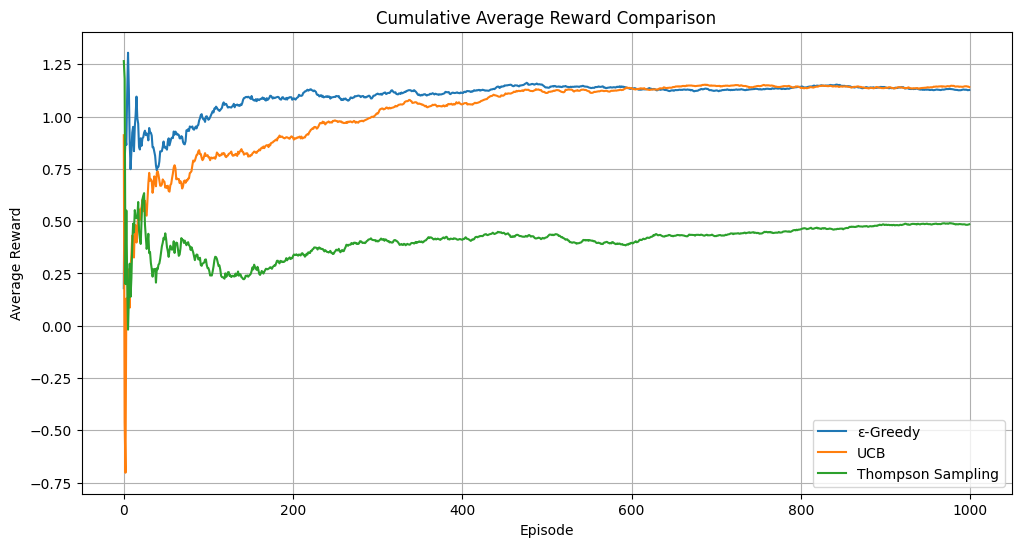

In [102]:

def plot_avg_rewards(*reward_lists, labels):
    plt.figure(figsize=(12, 6))
    for rewards, label in zip(reward_lists, labels):
        cumulative_avg = np.cumsum(rewards) / (np.arange(1, len(rewards) + 1))
        plt.plot(cumulative_avg, label=label)
    plt.title("Cumulative Average Reward Comparison")
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_avg_rewards(eps_rewards, ucb_rewards, ts_rewards,
                 labels=["ε-Greedy", "UCB", "Thompson Sampling"])
